# Week 39: Hartree-Fock theory -- the self-consistent field, $\langle a|\hat f|i\rangle = 0$, Thouless' theorem and stability

FYS4480/FYS9480, September 24-25, 2026. Companion notebook to `WeeklySlides/week39.pdf`.

Everything below is self-contained numpy. The code mirrors `BookPrograms/chapter06/hartreefock.py`
(classes `SelfConsistentField`, `OrbitalVariation`, `ThoulessRotation`, `LipkinHF`, `StabilityMatrix`),
and repeats the bit-pattern machinery of week 38 so that nothing has to be imported.

Contents:

1. The self-consistent field loop for the trap system; Brillouin's theorem at convergence
2. Varying one orbital: $a_a^\dagger a_i|\Phi_0\rangle$, $\langle\Phi_0|\hat H|\Phi_i^a\rangle = f_{ia}$, and $E(\eta)$
3. Thouless' theorem, verified in the determinant basis
4. Stability: the matrix $\hat M$ for the Lipkin model and for the pairing model
5. Numerical parts of the answers to the week-38 exercises


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from math import comb, factorial, pi
np.set_printoptions(precision=6, suppress=True, linewidth=120)
rng = np.random.default_rng(2039)


## 0. Determinants as bit patterns (week 38, repeated)

A determinant with $N$ particles in $n$ orbitals is an integer with $N$ bits set; $a_p^\dagger$ and $a_p$ act by setting or clearing bit $p$ with the phase $(-1)^{\text{number of occupied orbitals below } p}$. `hamiltonian_matrix` builds $\hat H = \sum h_{pq} a_p^\dagger a_q + \tfrac14\sum\langle pq|v|rs\rangle a_p^\dagger a_q^\dagger a_s a_r$ in the basis of all $\binom{n}{N}$ determinants.

In [2]:
def popcount(x):
    return bin(x).count("1")

def bits(state, n):
    return "|" + "".join(str((state >> p) & 1) for p in range(n)) + ">"

def annihilate(state, p):
    if not (state >> p) & 1:
        return 0, 0
    return (-1) ** popcount(state & ((1 << p) - 1)), state ^ (1 << p)

def create(state, p):
    if (state >> p) & 1:
        return 0, 0
    return (-1) ** popcount(state & ((1 << p) - 1)), state | (1 << p)

def apply_string(state, operators):
    '''operators = [(index, dagger), ...] leftmost first; rightmost acts first.'''
    sign = 1
    for p, dagger in reversed(operators):
        s, state = (create(state, p) if dagger else annihilate(state, p))
        if s == 0:
            return 0, 0
        sign *= s
    return sign, state

def determinant_basis(n, N):
    states = [sum(1 << p for p in occ) for occ in combinations(range(n), N)]
    return sorted(states)

def hamiltonian_matrix(h0, v, states, index):
    '''H in the determinant basis; v[p,q,r,s] = <pq|v|rs>_AS.'''
    n = h0.shape[0]
    H = np.zeros((len(states), len(states)))
    for col, state in enumerate(states):
        occ = [p for p in range(n) if (state >> p) & 1]
        for q in occ:
            for p in range(n):
                if h0[p, q] != 0.0:
                    s, new = apply_string(state, [(p, True), (q, False)])
                    if s: H[index[new], col] += s * h0[p, q]
        for r in occ:
            for t in occ:
                if t == r: continue
                for p in range(n):
                    for q in range(n):
                        if v[p, q, r, t] != 0.0:
                            s, new = apply_string(state, [(p, True), (q, True), (t, False), (r, False)])
                            if s: H[index[new], col] += 0.25 * s * v[p, q, r, t]
    return H

def transform_integrals(h0, v, C):
    '''h0 and v in the orbital basis whose columns are C[:, p].'''
    return C.T @ h0 @ C, np.einsum("ap,bq,abcd,cr,ds->pqrs", C, C, v, C, C)


## 1. The self-consistent field loop (sections 6.4-6.5)

Spinless fermions in a one-dimensional oscillator trap with a softened Coulomb repulsion, eight oscillator orbitals. The Fock matrix is $h^{\rm HF}_{\alpha\beta} = \langle\alpha|h_0|\beta\rangle + \sum_{\gamma\delta}\rho_{\gamma\delta}\langle\alpha\gamma|v|\beta\delta\rangle_{\rm AS}$ with the density matrix $\rho = C_{\rm occ}C_{\rm occ}^\dagger$, the projector onto the occupied subspace. Each iteration is one `eigh`.

In [4]:
def trap_system(n_orbitals=8, strength=1.0, softening=0.5):
    from numpy.polynomial.hermite import hermval
    grid = np.linspace(-8.0, 8.0, 401); dx = grid[1] - grid[0]
    phi = np.zeros((n_orbitals, grid.size))
    for k in range(n_orbitals):
        coef = np.zeros(k + 1); coef[k] = 1.0
        phi[k] = hermval(grid, coef) * np.exp(-0.5 * grid**2) / np.sqrt(2.0**k * factorial(k) * np.sqrt(pi))
    h0 = np.diag(np.arange(n_orbitals) + 0.5)
    interaction = strength / np.sqrt((grid[:, None] - grid[None, :])**2 + softening**2)
    direct = np.einsum("ax,by,xy,cx,dy->abcd", phi, phi, interaction * dx * dx, phi, phi)
    return h0, direct - direct.transpose(0, 1, 3, 2)

class SelfConsistentField:
    def __init__(self, h0, v, N):
        self.h0, self.v, self.N, self.n = h0, v, N, h0.shape[0]
    def density(self, C):
        occ = C[:, :self.N]; return occ @ occ.T
    def fock(self, rho):
        return self.h0 + np.einsum("gd,agbd->ab", rho, self.v)
    def energy(self, C):
        occ = C[:, :self.N]
        return (np.einsum("ai,ab,bi->", occ, self.h0, occ)
                + 0.5 * np.einsum("ai,bj,abcd,ci,dj->", occ, occ, self.v, occ, occ))
    def run(self, tol=1e-10, max_iter=200):
        C, eps_old, self.history = np.eye(self.n), np.zeros(self.n), []
        for it in range(1, max_iter + 1):
            eps, C = np.linalg.eigh(self.fock(self.density(C)))
            drift = np.abs(eps - eps_old).sum() / self.n
            self.history.append((it, self.energy(C), drift))
            if drift < tol: break
            eps_old = eps
        self.C, self.eps, self.E, self.iterations = C, eps, self.energy(C), it
        return self.E
    def brillouin(self):
        f = self.C.T @ self.fock(self.density(self.C)) @ self.C
        return np.abs(f[self.N:, :self.N]).max()

h0, v = trap_system(8)
print(f"{'N':>3} {'iterations':>11} {'E(reference)':>14} {'E(HF)':>14} {'gain':>11}")
for N in (2, 3, 4):
    scf = SelfConsistentField(h0, v, N)
    e_ref = scf.energy(np.eye(8)); e_hf = scf.run()
    print(f"{N:>3} {scf.iterations:>11} {e_ref:>14.8f} {e_hf:>14.8f} {e_hf-e_ref:>11.2e}")
scf = SelfConsistentField(h0, v, 4); scf.run()
rho = scf.density(scf.C)
print("\nrho^2 = rho:", np.abs(rho @ rho - rho).max() < 1e-12, ";  tr rho =", round(np.trace(rho), 10))
print(f"Brillouin at convergence: max |f_ai| = {scf.brillouin():.2e}")
hT, vT = transform_integrals(h0, v, scf.C)
print(f"E_HF = sum_i eps_i - 1/2 sum_ij <ij|v|ij> = {scf.eps[:4].sum() - 0.5 * sum(vT[i, j, i, j] for i in range(4) for j in range(4)):.8f}  (direct: {scf.E:.8f})")


  N  iterations   E(reference)          E(HF)        gain
  2          17     2.69018342     2.66308878   -2.71e-02
  3          17     6.46801021     6.39016133   -7.78e-02
  4          17    11.77084712    11.62305385   -1.48e-01

rho^2 = rho: True ;  tr rho = 4.0
Brillouin at convergence: max |f_ai| = 8.72e-11
E_HF = sum_i eps_i - 1/2 sum_ij <ij|v|ij> = 11.62305385  (direct: 11.62305385)


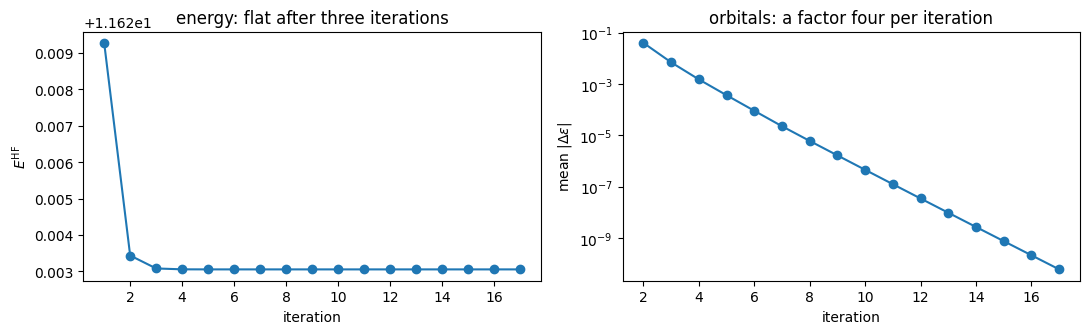

In [4]:
it, energies, drifts = zip(*scf.history)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(it, energies, "o-"); ax[0].set_xlabel("iteration"); ax[0].set_ylabel(r"$E^{\rm HF}$"); ax[0].set_title("energy: flat after three iterations")
ax[1].semilogy(it[1:], drifts[1:], "o-"); ax[1].set_xlabel("iteration"); ax[1].set_ylabel(r"mean $|\Delta\varepsilon|$"); ax[1].set_title("orbitals: a factor four per iteration")
fig.tight_layout(); plt.show()


## 2. Varying one orbital: $\langle a|\hat f|i\rangle = 0$ (section 6.6)

The variation $\phi_i \to N_i(\phi_i + \eta\phi_a)$ turns the determinant into $N_i(|\Phi_0\rangle + \eta\, a_a^\dagger a_i|\Phi_0\rangle)$, and

$$E(\eta) = \frac{E_0 + \eta^* f_{ai} + \eta f_{ia} + |\eta|^2\langle\Phi_i^a|\hat H|\Phi_i^a\rangle}{1+|\eta|^2}
= E_0 + 2\,{\rm Re}(\eta f_{ia}) + |\eta|^2\bigl(\langle\Phi_i^a|\hat H|\Phi_i^a\rangle - E_0\bigr) + O(\eta^3),$$

with $f$ the Fock matrix built from $|\Phi_0\rangle$ (whatever determinant that is). Three checks in the 70-determinant space: $a_a^\dagger a_i$ on the bit pattern is the pattern with $i \to a$ (up to the re-ordering sign $(-1)^{\#\text{occupied between}}$); $\langle\Phi_0|\hat H|\Phi_i^a\rangle = f_{ia}$ for all 16 pairs; the odd part of $E(\eta)$ is $2\,{\rm Re}(\eta f_{ia})$ -- non-zero in the oscillator basis, zero in the Hartree-Fock basis.

In [5]:
class OrbitalVariation:
    def __init__(self, h0, v, N):
        self.h0, self.v, self.N, self.n = h0, v, N, h0.shape[0]
        self.states = determinant_basis(self.n, N); self.index = {s: k for k, s in enumerate(self.states)}
        self.H = hamiltonian_matrix(h0, v, self.states, self.index)
        self.reference = (1 << N) - 1; self.r = self.index[self.reference]; self.E0 = self.H[self.r, self.r]
        rho = np.diag([1.0] * N + [0.0] * (self.n - N))
        self.f = h0 + np.einsum("gd,agbd->ab", rho, v)
        self.pairs = [(a, i) for a in range(N, self.n) for i in range(N)]
    def excitation(self, a, i):
        s, new = apply_string(self.reference, [(a, True), (i, False)]); return s, self.index[new]
    def replacement_check(self):
        worst = 0
        for a, i in self.pairs:
            s, idx = self.excitation(a, i)
            between = sum(1 for p in range(i + 1, a) if (self.reference >> p) & 1)
            worst = max(worst, abs(s - (-1) ** between), abs(self.states[idx] - ((self.reference ^ (1 << i)) | (1 << a))))
        return worst
    def matrix_elements(self):
        return max(abs(self.excitation(a, i)[0] * self.H[self.r, self.excitation(a, i)[1]] - self.f[i, a]) for a, i in self.pairs)
    def energy(self, a, i, eta):
        s, idx = self.excitation(a, i)
        psi = np.zeros(len(self.states), dtype=complex); psi[self.r] = 1.0; psi[idx] = eta * s
        return (psi.conj() @ self.H @ psi).real / (psi.conj() @ psi).real
    def odd_part(self, a, i, eta):
        return 0.5 * (self.energy(a, i, eta) - self.energy(a, i, -eta))

for label, (h, w) in (("oscillator basis", (h0, v)), ("Hartree-Fock basis", (hT, vT))):
    var = OrbitalVariation(h, w, 4)
    a, i = max(var.pairs, key=lambda p: abs(var.f[p[1], p[0]]))
    print(f"--- reference = first 4 orbitals of the {label}: E_0 = {var.E0:.8f}")
    print(f"    a_a^+ a_i |Phi_0> = pattern with i -> a, sign (-1)^between  (max error {var.replacement_check()})")
    print(f"    max |<Phi_0|H|Phi_i^a> - f_ia| = {var.matrix_elements():.1e};   max |f_ai| = {max(abs(var.f[b, j]) for b, j in var.pairs):.2e}")
    print(f"    pair (a, i) = ({a}, {i}), f_ia = {var.f[i, a]:+.6f}")
    for eta in (0.1, 0.05, 0.05j, 0.05 * np.exp(0.7j)):
        print(f"       eta = {str(np.round(eta, 4)):>16}: E - E_0 = {var.energy(a, i, eta) - var.E0:+.8f}, odd part = {var.odd_part(a, i, eta):+.3e}, 2 Re(eta f_ia) = {2 * (eta * var.f[i, a]).real:+.3e}")


--- reference = first 4 orbitals of the oscillator basis: E_0 = 11.77084712
    a_a^+ a_i |Phi_0> = pattern with i -> a, sign (-1)^between  (max error 0)
    max |<Phi_0|H|Phi_i^a> - f_ia| = 2.2e-15;   max |f_ai| = 4.34e-01
    pair (a, i) = (4, 2), f_ia = -0.433708
       eta =              0.1: E - E_0 = -0.06699359, odd part = -8.588e-02, 2 Re(eta f_ia) = -8.674e-02
       eta =             0.05: E - E_0 = -0.03850501, odd part = -4.326e-02, 2 Re(eta f_ia) = -4.337e-02
       eta =            0.05j: E - E_0 = +0.00475762, odd part = +0.000e+00, 2 Re(eta f_ia) = -0.000e+00
       eta = (0.0382+0.0322j): E - E_0 = -0.02833147, odd part = -3.309e-02, 2 Re(eta f_ia) = -3.317e-02
--- reference = first 4 orbitals of the Hartree-Fock basis: E_0 = 11.62305385
    a_a^+ a_i |Phi_0> = pattern with i -> a, sign (-1)^between  (max error 0)
    max |<Phi_0|H|Phi_i^a> - f_ia| = 2.3e-15;   max |f_ai| = 8.72e-11
    pair (a, i) = (4, 2), f_ia = -0.000000
       eta =              0.1: E - E_0 = +0.

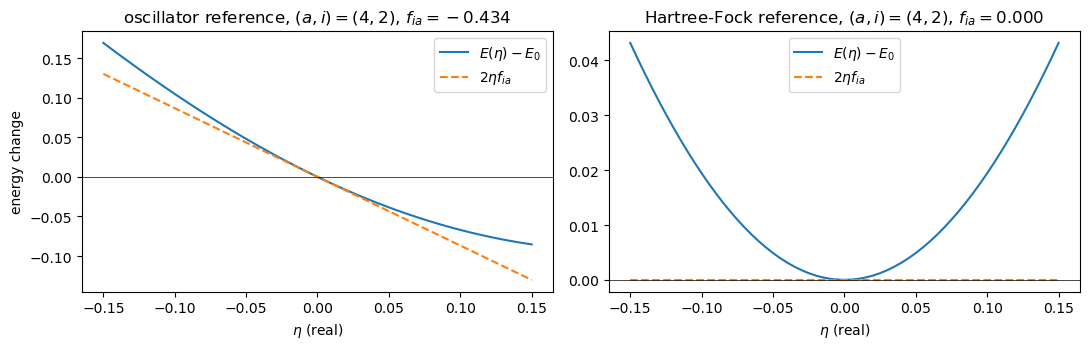

In [6]:
etas = np.linspace(-0.15, 0.15, 61)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for panel, (label, (h, w)) in zip(ax, (("oscillator reference", (h0, v)), ("Hartree-Fock reference", (hT, vT)))):
    var = OrbitalVariation(h, w, 4)
    a, i = max(var.pairs, key=lambda p: abs(var.f[p[1], p[0]]))
    panel.plot(etas, [var.energy(a, i, e) - var.E0 for e in etas], label=r"$E(\eta)-E_0$")
    panel.plot(etas, 2 * etas * var.f[i, a], "--", label=r"$2\eta f_{ia}$")
    panel.axhline(0, color="k", lw=0.5); panel.set_xlabel(r"$\eta$ (real)")
    panel.set_title(f"{label}, $(a,i)=({a},{i})$, $f_{{ia}}={var.f[i, a] if abs(var.f[i, a]) > 1e-9 else 0.0:.3f}$"); panel.legend()
ax[0].set_ylabel("energy change"); fig.tight_layout(); plt.show()


## 3. Thouless' theorem (section 6.7)

$|c'\rangle = \exp\{\sum_{ai} C_{ai} a_a^\dagger a_i\}|c\rangle$ is a single determinant, built from $b_i^\dagger = a_i^\dagger + \sum_a C_{ai}a_a^\dagger$. Six orbitals, three particles, random amplitudes of size 0.3. The exponential is computed as a finite series ($\hat T$ is nilpotent, $\hat T^{N+1} = 0$); the product state $\prod_i b_i^\dagger|0\rangle$ is expanded in the determinant basis through the minors of the $n\times N$ orbital matrix $D$ (chapter 2: the amplitude on a determinant is the determinant of the corresponding rows).

In [7]:
def expm_nilpotent(T, kmax=12):
    E, P = np.eye(T.shape[0]), np.eye(T.shape[0])
    for k in range(1, kmax + 1):
        P = P @ T / k
        if not P.any(): break
        E = E + P
    return E

n, N = 6, 3
C = 0.3 * rng.standard_normal((n - N, N))
states = determinant_basis(n, N); index = {s: k for k, s in enumerate(states)}
ref = (1 << N) - 1

def T_operator(hole=None):
    T = np.zeros((len(states), len(states)))
    for col, st in enumerate(states):
        for i in (range(N) if hole is None else (hole,)):
            for k, a in enumerate(range(N, n)):
                s, new = apply_string(st, [(a, True), (i, False)])
                if s: T[index[new], col] += C[k, i] * s
    return T

T = T_operator(); Ti = [T_operator(i) for i in range(N)]
vec0 = np.zeros(len(states)); vec0[index[ref]] = 1.0
psi_exp = expm_nilpotent(T) @ vec0
D = np.zeros((n, N))
for i in range(N):
    D[i, i] = 1.0
    for k, a in enumerate(range(N, n)): D[a, i] = C[k, i]
psi_prod = np.array([np.linalg.det(D[[p for p in range(n) if (st >> p) & 1], :]) for st in states])
print("max |[T_i, T_j]|                 :", f"{max(np.abs(Ti[i] @ Ti[j] - Ti[j] @ Ti[i]).max() for i in range(N) for j in range(N)):.1e}")
print("max |T_i^2|                      :", f"{max(np.abs(Ti[i] @ Ti[i]).max() for i in range(N)):.1e}")
print("|exp(T)|c> - prod_i b_i^+ |0>|   :", f"{np.abs(psi_exp - psi_prod).max():.1e}")
print("<c|exp(T)|c>                     :", f"{psi_exp[index[ref]]:.12f}")
print("det of the occupied block of D   :", f"{np.linalg.det(D[:N, :]):.12f}")
print("\nexp(sT)|c> against (1 + sT)|c>: the discarded piece is second order")
prev = None
for s in (0.4, 0.2, 0.1, 0.05, 0.025):
    err = np.abs(expm_nilpotent(s * T) @ vec0 - (np.eye(len(states)) + s * T) @ vec0).max()
    print(f"   s = {s:6.3f}   error = {err:.3e}" + (f"   ratio = {prev/err:.2f}" if prev else "")); prev = err
# the 2p-2h content of the discarded piece: which determinants carry it?
diff = expm_nilpotent(T) @ vec0 - (np.eye(len(states)) + T) @ vec0
levels = [popcount(st & ~ref) for st in states]
print("excitation levels carrying exp(T) - (1 + T):", sorted(set(levels[k] for k in range(len(states)) if abs(diff[k]) > 1e-14)))


max |[T_i, T_j]|                 : 2.8e-17
max |T_i^2|                      : 0.0e+00
|exp(T)|c> - prod_i b_i^+ |0>|   : 4.2e-17
<c|exp(T)|c>                     : 1.000000000000
det of the occupied block of D   : 1.000000000000

exp(sT)|c> against (1 + sT)|c>: the discarded piece is second order
   s =  0.400   error = 3.593e-02
   s =  0.200   error = 8.981e-03   ratio = 4.00
   s =  0.100   error = 2.245e-03   ratio = 4.00
   s =  0.050   error = 5.613e-04   ratio = 4.00
   s =  0.025   error = 1.403e-04   ratio = 4.00
excitation levels carrying exp(T) - (1 + T): [2, 3]


## 4. Stability of the Hartree-Fock solution (sections 6.10-6.11)

The stability matrix

$$\hat M = \begin{pmatrix}\Delta + A & B\\ B^* & \Delta + A^*\end{pmatrix},\qquad
(\Delta + A)_{ai,bj} = \langle\Phi_i^a|\hat H|\Phi_j^b\rangle - E_{\rm ref}\,\delta_{ab}\delta_{ij},\qquad
B_{ai,bj} = \langle\Phi_0|\hat H|\Phi_{ij}^{ab}\rangle,$$

built directly from the Hamiltonian in the determinant basis. The Hartree-Fock solution is a local minimum iff $\hat M \geq 0$.

In [8]:
class StabilityMatrix:
    def __init__(self, H, states, index, reference, N, n):
        self.H, self.states, self.index, self.ref, self.N, self.n = H, states, index, reference, N, n
        self.pairs = [(a, i) for a in range(N, n) for i in range(N)]
    def blocks(self):
        r = self.index[self.ref]; E_ref = self.H[r, r]; m = len(self.pairs)
        DA, B = np.zeros((m, m)), np.zeros((m, m))
        for x, (a, i) in enumerate(self.pairs):
            sa, ia = apply_string(self.ref, [(a, True), (i, False)]); ia = self.index[ia]
            for y, (b, j) in enumerate(self.pairs):
                sb, ib = apply_string(self.ref, [(b, True), (j, False)]); ib = self.index[ib]
                DA[x, y] = sa * sb * self.H[ia, ib] - (E_ref if x == y else 0.0)
                sd, idx = apply_string(self.ref, [(a, True), (b, True), (j, False), (i, False)])
                if sd: B[x, y] = sd * self.H[r, self.index[idx]]
        return DA, B
    def matrix(self):
        DA, B = self.blocks(); return np.block([[DA, B], [B, DA]])
    def eigenvalues(self):
        return np.linalg.eigvalsh(self.matrix())

def lipkin_matrix(N, eps, V):
    '''H = eps J_z + (V/2)(J_+^2 + J_-^2); bit p = (p, down), bit N + p = (p, up).'''
    states = determinant_basis(2 * N, N); index = {s: k for k, s in enumerate(states)}
    H = np.zeros((len(states), len(states)))
    for col, st in enumerate(states):
        up = sum(1 for p in range(N) if (st >> (N + p)) & 1)
        H[col, col] += 0.5 * eps * (2 * up - N)
        for p in range(N):
            for q in range(N):
                for ops in ([(N + p, True), (p, False), (N + q, True), (q, False)],
                            [(p, True), (N + p, False), (q, True), (N + q, False)]):
                    s, new = apply_string(st, ops)
                    if s: H[index[new], col] += 0.5 * V * s
    return H, states, index

N, eps = 4, 1.0
print("Lipkin model, N = 4, eps = 1, W = 0")
print(f"{'chi':>6} {'lambda_min(M)':>14} {'eps(1-chi)':>11} {'alpha_min':>10} {'E_mf':>10} {'E_exact':>10}")
chis, lams = np.linspace(0.05, 2.5, 40), []
for chi in (0.25, 0.5, 0.9, 1.0, 1.5, 2.0):
    V = chi * eps / (N - 1)
    H, states, index = lipkin_matrix(N, eps, V)
    lam = StabilityMatrix(H, states, index, (1 << N) - 1, N, 2 * N).eigenvalues()[0]
    alpha = np.arccos(1 / chi) if chi > 1 else 0.0
    E_mf = N * (-0.5 * eps * np.cos(alpha) - 0.25 * eps * chi * np.sin(alpha)**2)
    print(f"{chi:>6.2f} {lam:>14.8f} {eps*(1-chi):>11.4f} {alpha:>10.6f} {E_mf:>10.6f} {np.linalg.eigvalsh(H)[0]:>10.6f}")
for chi in chis:
    H, states, index = lipkin_matrix(N, eps, chi * eps / (N - 1))
    lams.append(StabilityMatrix(H, states, index, (1 << N) - 1, N, 2 * N).eigenvalues()[0])


Lipkin model, N = 4, eps = 1, W = 0
   chi  lambda_min(M)  eps(1-chi)  alpha_min       E_mf    E_exact
  0.25     0.75000000      0.7500   0.000000  -2.000000  -2.020726
  0.50     0.50000000      0.5000   0.000000  -2.000000  -2.081666
  0.90     0.10000000      0.1000   0.000000  -2.000000  -2.253886
  1.00    -0.00000000      0.0000   0.000000  -2.000000  -2.309401
  1.50    -0.50000000     -0.5000   0.841069  -2.166667  -2.645751
  2.00    -1.00000000     -1.0000   1.047198  -2.500000  -3.055050


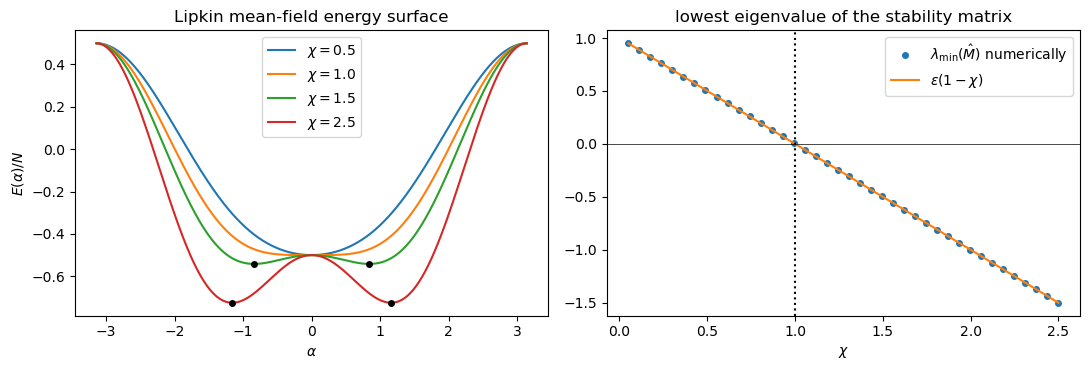

In [9]:
alpha = np.linspace(-np.pi, np.pi, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for chi in (0.5, 1.0, 1.5, 2.5):
    ax[0].plot(alpha, -0.5 * np.cos(alpha) - 0.25 * chi * np.sin(alpha)**2, label=rf"$\chi={chi}$")
    if chi > 1:
        am = np.arccos(1 / chi); ax[0].plot([am, -am], [-0.25 * (chi + 1 / chi)] * 2, "k.", ms=8)
ax[0].set_xlabel(r"$\alpha$"); ax[0].set_ylabel(r"$E(\alpha)/N$"); ax[0].set_title("Lipkin mean-field energy surface"); ax[0].legend()
ax[1].plot(chis, lams, "o", ms=4, label=r"$\lambda_{\min}(\hat M)$ numerically"); ax[1].plot(chis, 1 - chis, "-", label=r"$\varepsilon(1-\chi)$")
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(1, color="k", ls=":"); ax[1].set_xlabel(r"$\chi$"); ax[1].set_title("lowest eigenvalue of the stability matrix"); ax[1].legend()
fig.tight_layout(); plt.show()


**The pairing model is stable for every $g$ -- and Hartree-Fock is useless for it.** $A = 0$ (the pairing interaction cannot scatter a single particle-hole pair), $\Delta = \varepsilon_q - \varepsilon_p + g/2$, and $B$ couples $\delta C_{q\uparrow,p\uparrow}$ to $\delta C^*_{q\downarrow,p\downarrow}$ with $-g/2$. The $2\times2$ blocks of $\hat M$ have eigenvalues $\varepsilon_q-\varepsilon_p$ and $\varepsilon_q-\varepsilon_p+g$: the coherent rotation of a whole pair costs exactly the level spacing, the interaction cancels out, and $\lambda_{\min} = \varepsilon_3 - \varepsilon_2 = 1$ independently of $g$. A number-conserving mean field never captures pair correlations; the BCS state of chapter 7 does, by breaking particle-number symmetry instead.

In [10]:
def pairing_elements(levels, xi=1.0, g=1.0):
    '''orbital 2p = (p, up), 2p+1 = (p, down); single-particle energies xi*p.'''
    m = 2 * levels
    h = np.zeros((m, m)); v = np.zeros((m, m, m, m))
    for p in range(levels):
        h[2*p, 2*p] = h[2*p+1, 2*p+1] = xi * p
    for p in range(levels):
        for q in range(levels):
            pu, pd, qu, qd = 2*p, 2*p+1, 2*q, 2*q+1
            v[pu, pd, qu, qd] = v[pd, pu, qd, qu] = -g / 2
            v[pu, pd, qd, qu] = v[pd, pu, qu, qd] = +g / 2
    return h, v

states8 = determinant_basis(8, 4); index8 = {s: k for k, s in enumerate(states8)}
print(f"{'g':>5} {'lambda_min(M)':>14} {'lambda_min(Delta+A)':>20} {'max|A|':>8} {'max|B|':>8}")
for g in (0.25, 0.5, 1.0, 2.0, 3.0):
    hp, vp = pairing_elements(4, 1.0, g)
    Hp = hamiltonian_matrix(hp, vp, states8, index8)
    S = StabilityMatrix(Hp, states8, index8, 0b1111, 4, 8); DA, B = S.blocks()
    print(f"{g:>5.2f} {S.eigenvalues()[0]:>14.6f} {np.linalg.eigvalsh(DA)[0]:>20.6f} {np.abs(DA - np.diag(np.diag(DA))).max():>8.3f} {np.abs(B).max():>8.3f}")


    g  lambda_min(M)  lambda_min(Delta+A)   max|A|   max|B|
 0.25       1.000000             1.125000    0.000    0.125
 0.50       1.000000             1.250000    0.000    0.250
 1.00       1.000000             1.500000    0.000    0.500
 2.00       1.000000             2.000000    0.000    1.000
 3.00       1.000000             2.500000    0.000    1.500


## 5. Numerical parts of the answers to the week-38 exercises

Exercise 1 (bit patterns): the three examples and the quadruple count. Exercise 2 (the FCI equation from the variational principle): the two-level system, the $6\times6$ and $70\times70$ characteristic polynomials, interlacing. Exercise 3 (chapter 5, exercise 4): the two non-interacting copies.

In [11]:
def pattern(s):
    '''bit string with alpha_0 leftmost -> integer'''
    return sum(1 << p for p, ch in enumerate(s) if ch == "1")
def show(ops, pat):
    s, new = apply_string(pattern(pat), ops)
    return f"{s:+d} {bits(new, len(pat))}" if s else "0  (Pauli: creating in an occupied orbital)"
c = lambda p: (p, True); d = lambda p: (p, False)
print("1a)  a_3^+ a_1 |01011>            =", show([c(3), d(1)], "01011"))
print("     a_0^+ a_4 |01101>            =", show([c(0), d(4)], "01101"))
print("     a_4^+ a_3^+ a_1 a_0 |11010>  =", show([c(4), c(3), d(1), d(0)], "11010"))
print("     (a_2^+ a_1 |01011>           =", show([c(2), d(1)], "01011"), ")")
n, N = 40, 8
print(f"\n1c)  N(N-1)(n-N+2)(n-N+1) = {N*(N-1)*(n-N+2)*(n-N+1)} of n^4 = {n**4}: {100*N*(N-1)*(n-N+2)*(n-N+1)/n**4:.2f} %")
st = pattern("10100101")   # a random n = 8, N = 4 pattern
count = sum(1 for p in range(8) for q in range(8) for r in range(8) for t in range(8) if apply_string(st, [c(p), c(q), d(t), d(r)])[0])
print(f"     brute force for n = 8, N = 4: {count} non-zero quadruples, formula {4*3*6*5}")


1a)  a_3^+ a_1 |01011>            = 0  (Pauli: creating in an occupied orbital)
     a_0^+ a_4 |01101>            = +1 |11100>
     a_4^+ a_3^+ a_1 a_0 |11010>  = 0  (Pauli: creating in an occupied orbital)
     (a_2^+ a_1 |01011>           = +1 |00111> )

1c)  N(N-1)(n-N+2)(n-N+1) = 62832 of n^4 = 2560000: 2.45 %
     brute force for n = 8, N = 4: 360 non-zero quadruples, formula 360


In [12]:
xi = 1.0
print("2b) two levels, one pair: E_- = xi - g/2 - sqrt(xi^2 + g^2/4)  against  -g/2 - g^2/(8 xi)")
for g in (0.25, 0.5, 1.0):
    H2 = np.array([[-g/2, -g/2], [-g/2, 2*xi - g/2]])
    print(f"    g = {g:4.2f}: eigh {np.linalg.eigvalsh(H2)[0]:+.6f}, closed form {xi - g/2 - np.sqrt(xi**2 + g**2/4):+.6f}, 2nd order {-g/2 - g**2/(8*xi):+.6f}")

def seniority_zero_matrix(g, levels=4, xi=1.0):
    pairs = list(combinations(range(levels), 2))
    M = np.zeros((len(pairs), len(pairs)))
    for x, (p, q) in enumerate(pairs):
        M[x, x] = 2 * xi * (p + q) - g
        for y, (r, s) in enumerate(pairs):
            if x != y and len({p, q} & {r, s}) == 1: M[x, y] = -g / 2
    return M, pairs
H6, pairs6 = seniority_zero_matrix(1.0)
coeffs = np.poly(H6)
print("\n2c) 6x6 at g = 1, basis", [f"|{p+1}{q+1}>" for p, q in pairs6])
print("    characteristic polynomial, E^6 ... E^0:", np.round(coeffs, 6))
print("    trace =", np.trace(H6), ", det =", round(np.linalg.det(H6), 6))
print("    roots           :", np.sort(np.roots(coeffs).real))
print("    eigh            :", np.linalg.eigvalsh(H6))
hp, vp = pairing_elements(4, 1.0, 1.0)
H70 = hamiltonian_matrix(hp, vp, states8, index8); E70 = np.linalg.eigvalsh(H70); c70 = np.poly(H70)
print(f"    70x70: largest coefficient {np.abs(c70).max():.2e}; max |root - eigenvalue| from exact coefficients {np.abs(np.sort(np.roots(c70).real) - E70).max():.1e}")
pert = c70 * (1 + 1e-14 * rng.standard_normal(c70.size))
print(f"           after 1e-14 relative noise on the coefficients: {np.abs(np.sort(np.roots(pert).real) - E70).max():.1e}")
Hn = H70 + 1e-14 * np.abs(H70).max() * rng.standard_normal(H70.shape); Hn = (Hn + Hn.T) / 2
print(f"           after 1e-14 relative noise on the matrix      : {np.abs(np.linalg.eigvalsh(Hn) - E70).max():.1e}")
print("\n2d) interlacing: eigenvalues of the leading k x k blocks")
for k in range(1, 7):
    print(f"    k = {k}:", np.round(np.linalg.eigvalsh(H6[:k, :k]), 6))


2b) two levels, one pair: E_- = xi - g/2 - sqrt(xi^2 + g^2/4)  against  -g/2 - g^2/(8 xi)
    g = 0.25: eigh -0.132782, closed form -0.132782, 2nd order -0.132812
    g = 0.50: eigh -0.280776, closed form -0.280776, 2nd order -0.281250
    g = 1.00: eigh -0.618034, closed form -0.618034, 2nd order -0.625000

2c) 6x6 at g = 1, basis ['|12>', '|13>', '|14>', '|23>', '|24>', '|34>']
    characteristic polynomial, E^6 ... E^0: [    1.   -30.   352. -2038.  5979. -7940.  3100.]
    trace = 30.0 , det = 3100.0
    roots           : [0.635548 2.935381 5.       5.       7.20894  9.22013 ]
    eigh            : [0.635548 2.935381 5.       5.       7.20894  9.22013 ]
    70x70: largest coefficient 9.61e+54; max |root - eigenvalue| from exact coefficients 1.3e+01
           after 1e-14 relative noise on the coefficients: 1.4e+01
           after 1e-14 relative noise on the matrix      : 4.4e-13

2d) interlacing: eigenvalues of the leading k x k blocks
    k = 1: [1.]
    k = 2: [0.881966 3.118034

In [13]:
def copies_elements(ncopies, xi=1.0, g=1.0):
    m = 4 * ncopies
    h = np.zeros((m, m)); v = np.zeros((m, m, m, m))
    for cpy in range(ncopies):
        o = 4 * cpy
        for s in (0, 1): h[o + 2 + s, o + 2 + s] = xi
        for p in range(2):
            for q in range(2):
                pu, pd, qu, qd = o+2*p, o+2*p+1, o+2*q, o+2*q+1
                v[pu, pd, qu, qd] = v[pd, pu, qd, qu] = -g / 2
                v[pu, pd, qd, qu] = v[pd, pu, qu, qd] = +g / 2
    return h, v

def truncated(H, states, reference, levels):
    lev = [popcount(s & ~reference) for s in states]
    keep = [k for k in range(len(states)) if lev[k] in levels]
    return H[np.ix_(keep, keep)]

print("3b) two non-interacting two-level pairing systems")
print(f"{'g':>5} {'2 E(A)':>13} {'E(AB) FCI':>13} {'E(AB) CID':>13} {'CID error':>11} {'E(AB) CISDTQ':>13}")
s4 = determinant_basis(4, 2); i4 = {s: k for k, s in enumerate(s4)}
for g in (0.25, 0.5, 1.0):
    h1, v1 = copies_elements(1, 1.0, g); EA = np.linalg.eigvalsh(hamiltonian_matrix(h1, v1, s4, i4))[0]
    h2, v2 = copies_elements(2, 1.0, g); HAB = hamiltonian_matrix(h2, v2, states8, index8)
    ref = 0b00110011
    EAB = np.linalg.eigvalsh(HAB)[0]
    ECID = np.linalg.eigvalsh(truncated(HAB, states8, ref, {0, 2}))[0]
    EQ = np.linalg.eigvalsh(truncated(HAB, states8, ref, {0, 1, 2, 3, 4}))[0]
    print(f"{g:>5.2f} {2*EA:>13.8f} {EAB:>13.8f} {ECID:>13.8f} {ECID-EAB:>11.2e} {EQ:>13.8f}")
# the one-parameter exponential ansatz (1 + t A^A)(1 + t A^B)|Phi_0>
h2, v2 = copies_elements(2, 1.0, 1.0); HAB = hamiltonian_matrix(h2, v2, states8, index8)
ref, A_only, B_only, both = 0b00110011, 0b00111100, 0b11000011, 0b11001100
def cc_energy(t):
    vec = np.zeros(len(states8)); vec[index8[ref]] = 1; vec[index8[A_only]] = t; vec[index8[B_only]] = t; vec[index8[both]] = t * t
    return vec @ HAB @ vec / (vec @ vec)
ts = np.linspace(0, 0.5, 5001); Ecc = [cc_energy(t) for t in ts]
print(f"    exp(T_2) with one parameter: minimum {min(Ecc):.8f} at t = {ts[int(np.argmin(Ecc))]:.4f}, FCI {np.linalg.eigvalsh(HAB)[0]:.8f}")


3b) two non-interacting two-level pairing systems
    g        2 E(A)     E(AB) FCI     E(AB) CID   CID error  E(AB) CISDTQ
 0.25   -0.26556444   -0.26556444   -0.26550480    5.96e-05   -0.26556444
 0.50   -0.56155281   -0.56155281   -0.56066017    8.93e-04   -0.56155281
 1.00   -1.23606798   -1.23606798   -1.22474487    1.13e-02   -1.23606798
    exp(T_2) with one parameter: minimum -1.23606797 at t = 0.2361, FCI -1.23606798
